In [1]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from peft import AdaLoraConfig,get_peft_model

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.9 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
file_path="/content/drive/MyDrive/Yelp Reviews (5 Classes).csv"

df=pd.read_csv(
    file_path,
    encoding='ISO-8859-1'
)

df=df[['Text','Sentiment']].dropna()

total_instances=len(df)

print(f"Total instances:{total_instances}")

print(df['Sentiment'].value_counts())


sentiment_to_label={

    "Very Negative":0,
    "Negative":1,
    "Neutral":2,
    "Positive":3,
    "Very Positive":4
}


df['label']=df['Sentiment'].map(
    sentiment_to_label
)


print("\nNumber of instances per label:")

print(
    df['label'].value_counts().sort_index()
)


train_texts,temp_texts,train_labels,temp_labels=train_test_split(

    df['Text'].tolist(),
    df['label'].tolist(),

    test_size=0.2,

    random_state=42,

    stratify=df['label']
)


val_texts,test_texts,val_labels,test_labels=train_test_split(

    temp_texts,
    temp_labels,

    test_size=0.5,

    random_state=42,

    stratify=temp_labels
)

print(
f"\nTrain size:{len(train_texts)} | Val size:{len(val_texts)} | Test size:{len(test_texts)}"
)

Total instances:6871
Sentiment
Neutral          1591
Negative         1522
Positive         1398
Very Negative    1204
Very Positive    1156
Name: count, dtype: int64

Number of instances per label:
label
0    1204
1    1522
2    1591
3    1398
4    1156
Name: count, dtype: int64

Train size:5496 | Val size:687 | Test size:688


In [3]:
model_name="bert-base-multilingual-uncased"

tokenizer=AutoTokenizer.from_pretrained(
    model_name
)

train_enc=tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

val_enc=tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_enc=tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)


class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self,encodings,labels):

        self.encodings=encodings
        self.labels=labels

    def __getitem__(self,idx):

        return {

            k:torch.tensor(v[idx])

            for k,v in self.encodings.items()

        } | {

            'labels':torch.tensor(
                self.labels[idx]
            )
        }

    def __len__(self):

        return len(self.labels)


train_ds=ReviewDataset(
    train_enc,
    train_labels
)

val_ds=ReviewDataset(
    val_enc,
    val_labels
)

test_ds=ReviewDataset(
    test_enc,
    test_labels
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
def compute_metrics(eval_pred):

    logits,labels=eval_pred

    preds=np.argmax(
        logits,
        axis=1
    )

    acc=accuracy_score(
        labels,
        preds
    )*100


    prec,rec,f1,_=precision_recall_fscore_support(

        labels,
        preds,
        average='macro'
    )


    return {

        "Accuracy":acc,

        "Precision":prec*100,

        "Recall":rec*100,

        "F1 Score":f1*100
    }

In [5]:
model=AutoModelForSequenceClassification.from_pretrained(

    model_name,

    num_labels=5
)


adalora_cfg=AdaLoraConfig(

    task_type="SEQ_CLS",

    init_r=12,
    target_r=8,

    beta1=0.85,
    beta2=0.85,

    tinit=200,
    tfinal=1000,
    deltaT=10,

    lora_alpha=32,

    lora_dropout=0.1,

    target_modules=[
        "query",
        "value"
    ]
)


model=get_peft_model(
    model,
    adalora_cfg
)

model.print_trainable_parameters()


args=TrainingArguments(

    output_dir="./adalora-mbert",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    fp16=True,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",

    greater_is_better=False,

    report_to="none",

    save_total_limit=2
)


trainer=Trainer(

    model=model,

    args=args,

    train_dataset=train_ds,

    eval_dataset=val_ds,

    compute_metrics=compute_metrics
)

start=time.time()

train_output=trainer.train()

training_time=time.time()-start

metrics=trainer.evaluate(
    test_ds
)

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 446,501 || all params: 167,806,786 || trainable%: 0.2661


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,1.737000,1.593919,23.144105,10.318653,20.392633,11.321332
2,1.596700,1.406124,35.807860,41.613397,34.782235,33.985930
3,1.339200,1.261602,40.756914,44.082095,40.109951,37.656778
4,1.278100,1.233738,41.630277,43.305231,42.717726,42.597652
5,1.237800,1.219079,41.775837,42.281822,43.214797,41.983766


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is dep

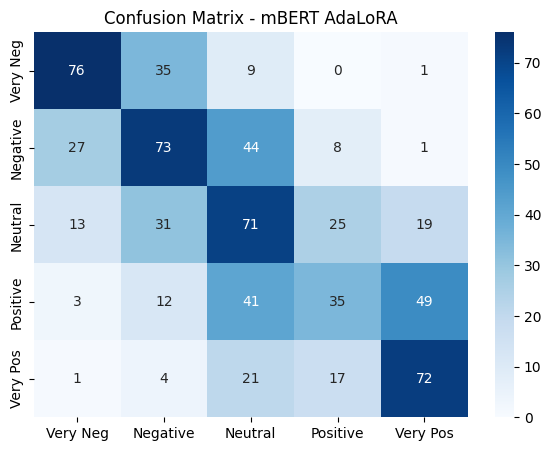

In [6]:
preds_out=trainer.predict(
    test_ds
)

preds=np.argmax(
    preds_out.predictions,
    axis=1
)

cm=confusion_matrix(
    test_ds.labels,
    preds,
    labels=[0,1,2,3,4]
)

plt.figure(figsize=(7,5))

sns.heatmap(

    cm,

    annot=True,
    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Very Neg",
        "Negative",
        "Neutral",
        "Positive",
        "Very Pos"
    ],

    yticklabels=[
        "Very Neg",
        "Negative",
        "Neutral",
        "Positive",
        "Very Pos"
    ]
)

plt.title(
    "Confusion Matrix - mBERT AdaLoRA"
)

plt.show()

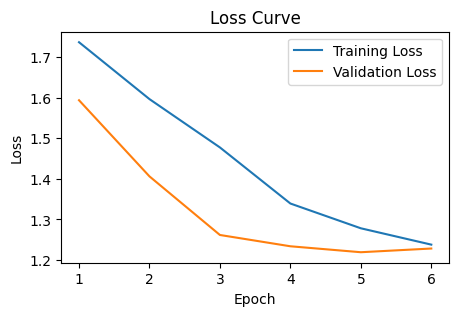

In [7]:
history=trainer.state.log_history


train_loss=[

    x["loss"]

    for x in history

    if "loss" in x
]


eval_loss=[

    x["eval_loss"]

    for x in history

    if "eval_loss" in x
]


plt.figure(figsize=(5,3))

plt.plot(
    range(1,len(train_loss)+1),
    train_loss,
    label="Training Loss"
)

plt.plot(
    range(1,len(eval_loss)+1),
    eval_loss,
    label="Validation Loss"
)

plt.title(
    "Loss Curve"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(False)

plt.show()

In [8]:
probs=torch.softmax(

    torch.tensor(
        preds_out.predictions
    ),

    dim=1
)

confidence=probs.max(
    dim=1
).values.numpy().mean()*100


labels_onehot=np.eye(
    5
)[test_ds.labels]


similarity=cosine_similarity(

    preds_out.predictions,
    labels_onehot
).mean()*100


results={

"Model":"AdaLoRA mBERT",

"Accuracy":
f"{metrics['eval_Accuracy']:.2f}%",

"Precision":
f"{metrics['eval_Precision']:.2f}%",

"Recall":
f"{metrics['eval_Recall']:.2f}%",

"F1 Score":
f"{metrics['eval_F1 Score']:.2f}%",

"Similarity":
f"{similarity:.2f}%",

"Confidence":
f"{confidence:.2f}%",

"Training Time (s)":
f"{training_time:.2f}",

"Trainable Params":
sum(
p.numel()
for p in model.parameters()
if p.requires_grad
),

"GPU Memory (GB)":
f"{torch.cuda.max_memory_allocated()/1024**3:.4f}"

}

comparison_df=pd.DataFrame(
    [results]
)

print(
comparison_df.to_string(index=False)
)

        Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s)  Trainable Params GPU Memory (GB)
AdaLoRA mBERT   47.53%    48.10% 48.56%   47.75%      2.01%     44.49%            398.19            446501          1.4494
